# 1. Introduction

# Spaceship Titanic

## Problem Overview

In this competition, we are given passenger data from the Spaceship Titanic.  
Our objective is to predict whether a passenger was **transported to another dimension** during the accident.

This notebook focuses on:

- add after finish


---

## Dataset Description

The dataset contains information about passengers such as:

- Demographics (Age, HomePlanet)
- Travel details (Destination, Cabin)
- Spending behavior (RoomService, Spa, VRDeck, etc.)
- Group information (PassengerId)
- Target variable: `Transported`

We are provided with:
- `train.csv` → labeled training data
- `test.csv` → unlabeled test data

# 2. Library Imports & Data Loading

In this section:

- Import required Python libraries
- Load the training and test datasets
- Inspect basic dataset structure
- Check for missing values

In [1]:
import numpy as np
import pandas as pd

import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
train_path = 'data/spaceship-titanic/train.csv'
test_path = 'data/spaceship-titanic/test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print('Train set shape:', train.shape)
print('Test set shape:', test.shape)
train.head()

Train set shape: (8693, 14)
Test set shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [4]:
print('Aggregated train missing values:')
print(train.isna().sum())
print('')
print('Aggregated test missing values')
print(test.isna().sum())

Aggregated train missing values:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

Aggregated test missing values
PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64


## Missing Values Visualization

We use the `missingno` library to:

- Visualize missing data patterns
- Detect potential relationships between missing variables

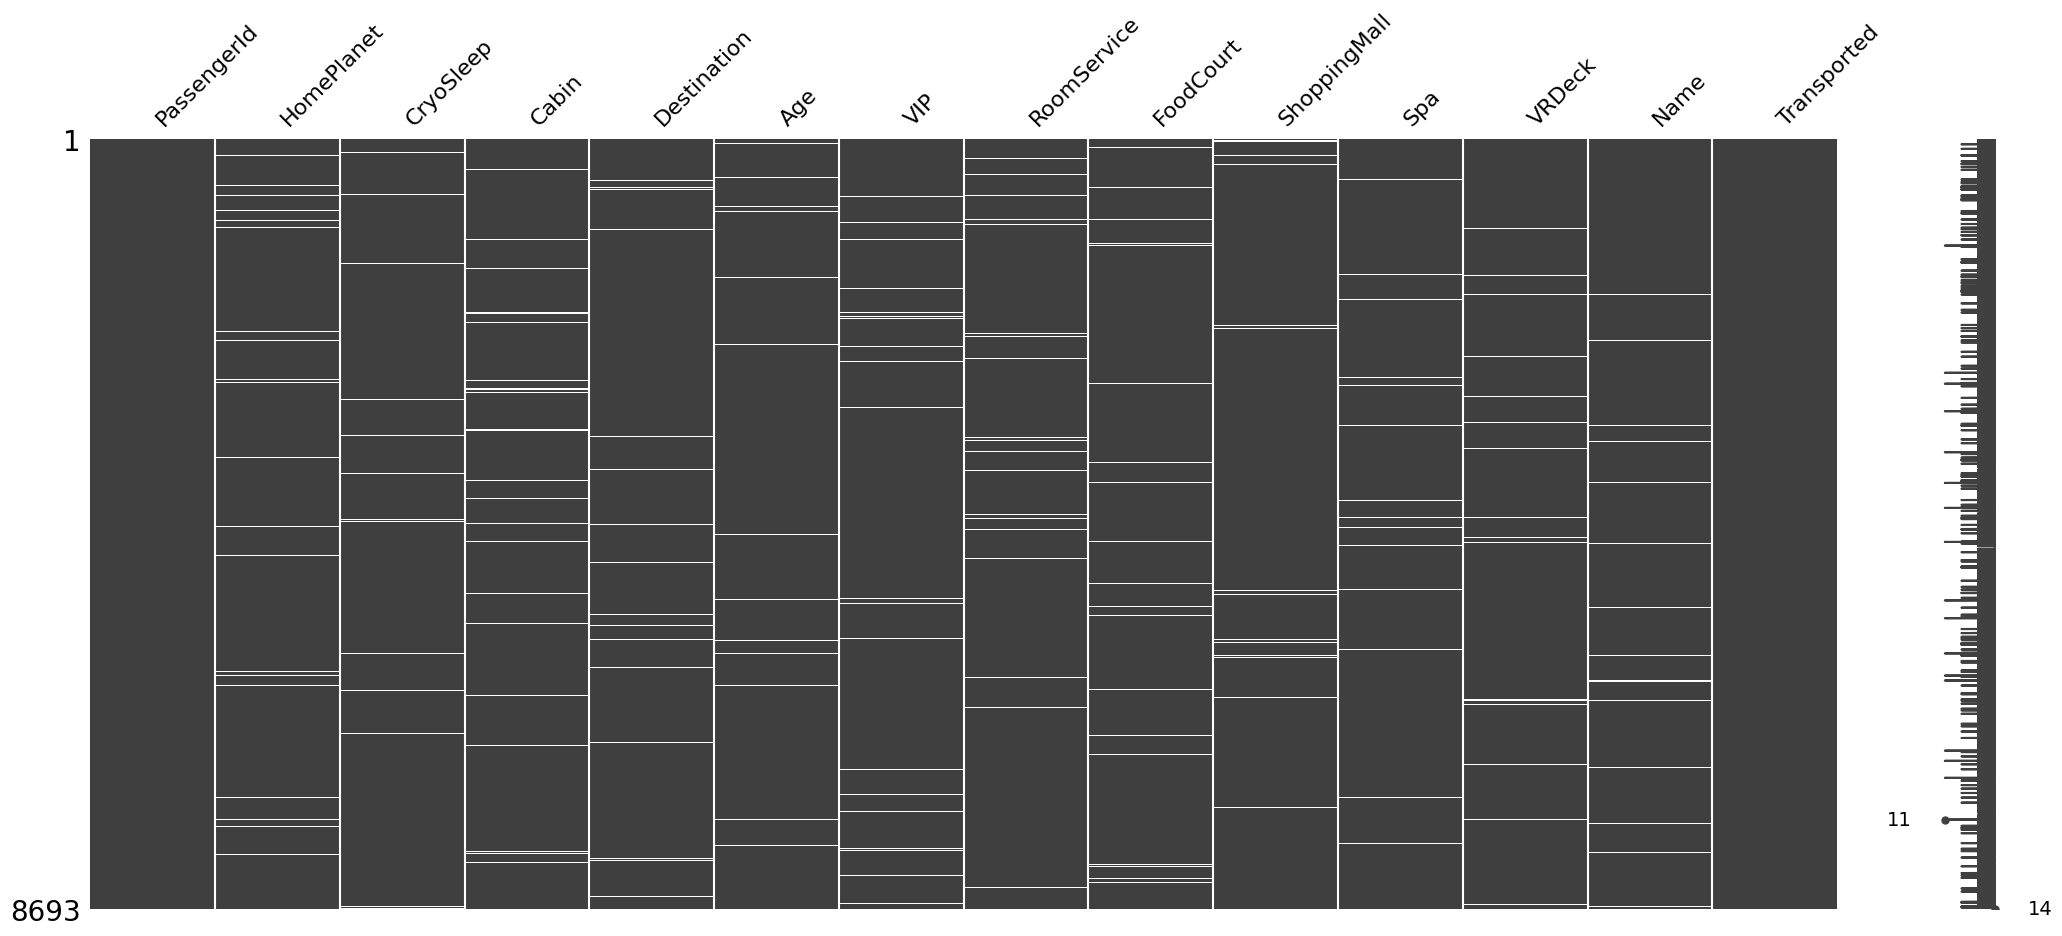

In [5]:
msno.matrix(train)
plt.show()

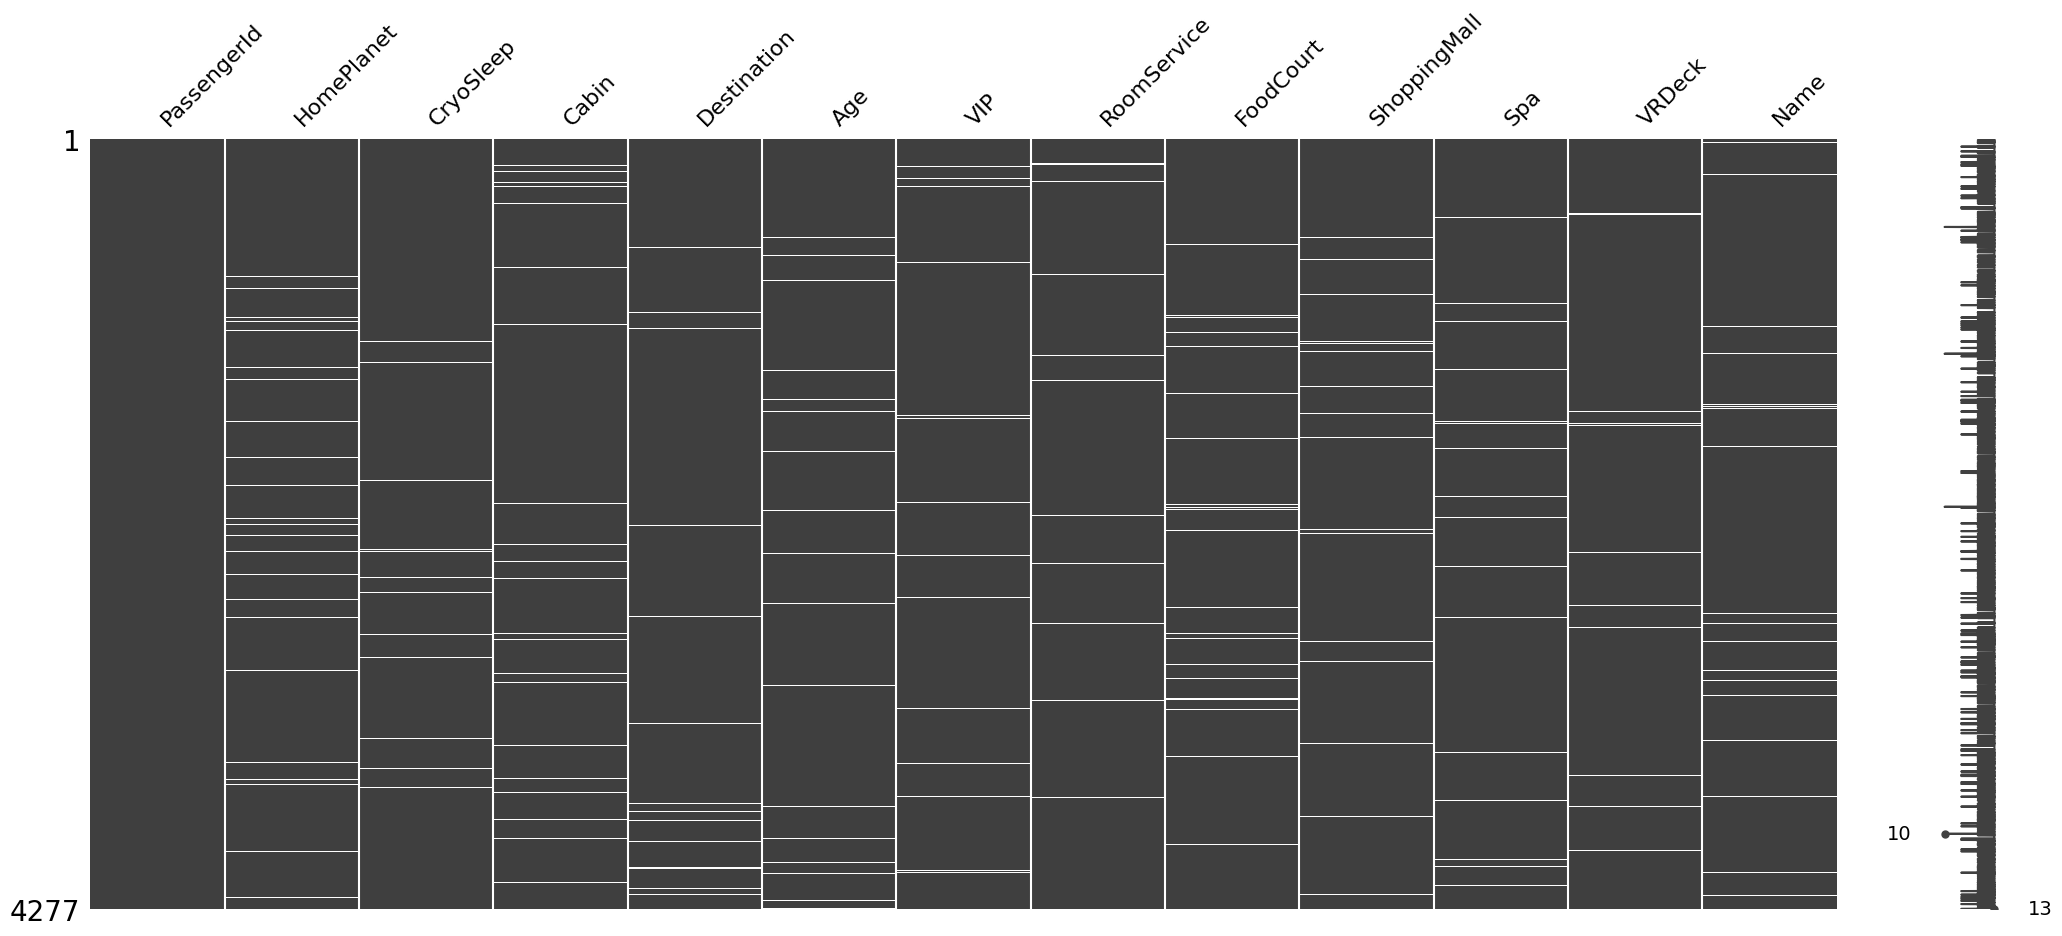

In [6]:
msno.matrix(test)
plt.show()

In [7]:
train.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

# 3. Exploratory Data Analysis

The goal of this section is to understand:

- Distribution of numerical variables
- Distribution of categorical variables
- Relationship between features and the target (`Transported`)

---

## Target Distribution

We first examine the distribution of the target variable to understand class balance.




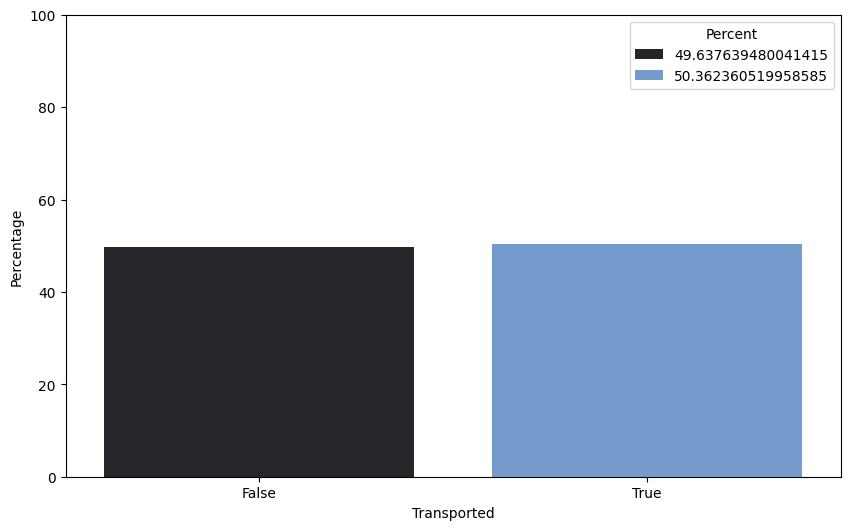

In [8]:
plt.figure(figsize = (10,6))

percentages = (train['Transported'].value_counts(normalize = True).mul(100).reset_index())
percentages.columns = ['Transported', 'Percent']

sns.barplot(data = percentages, x = 'Transported', y = 'Percent', hue = 'Percent', palette = 'dark:#69d')

plt.ylabel("Percentage")
plt.ylim(0, 100)
plt.show()

## Numerical Feature Analysis

We analyze:

- Age distribution
- Spending features
- Group size distribution
- Cabin number distribution

Histograms are used to observe:

- Skewness
- Outliers
- Separation between transported and non-transported passengers


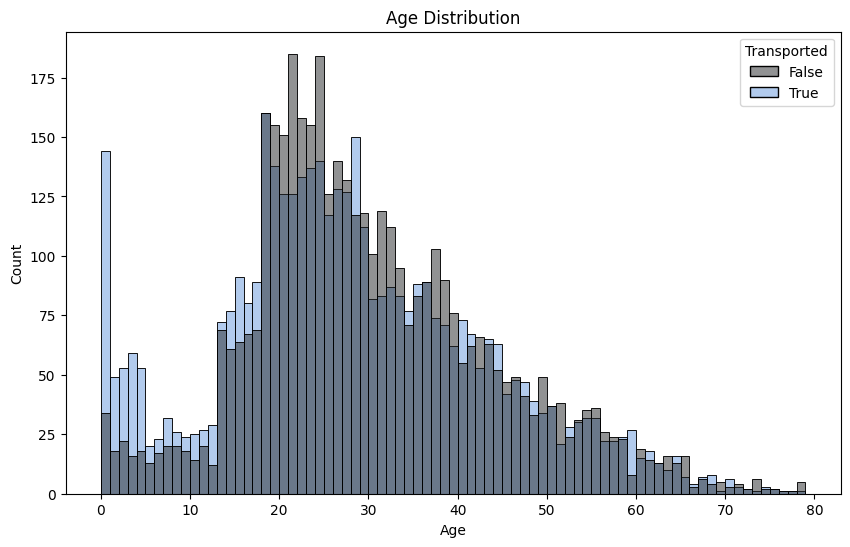

In [9]:
plt.figure(figsize = (10,6))

sns.histplot(data = train, x = 'Age', hue = 'Transported', binwidth = 1, palette = 'dark:#69d')

plt.title('Age Distribution')
plt.show()

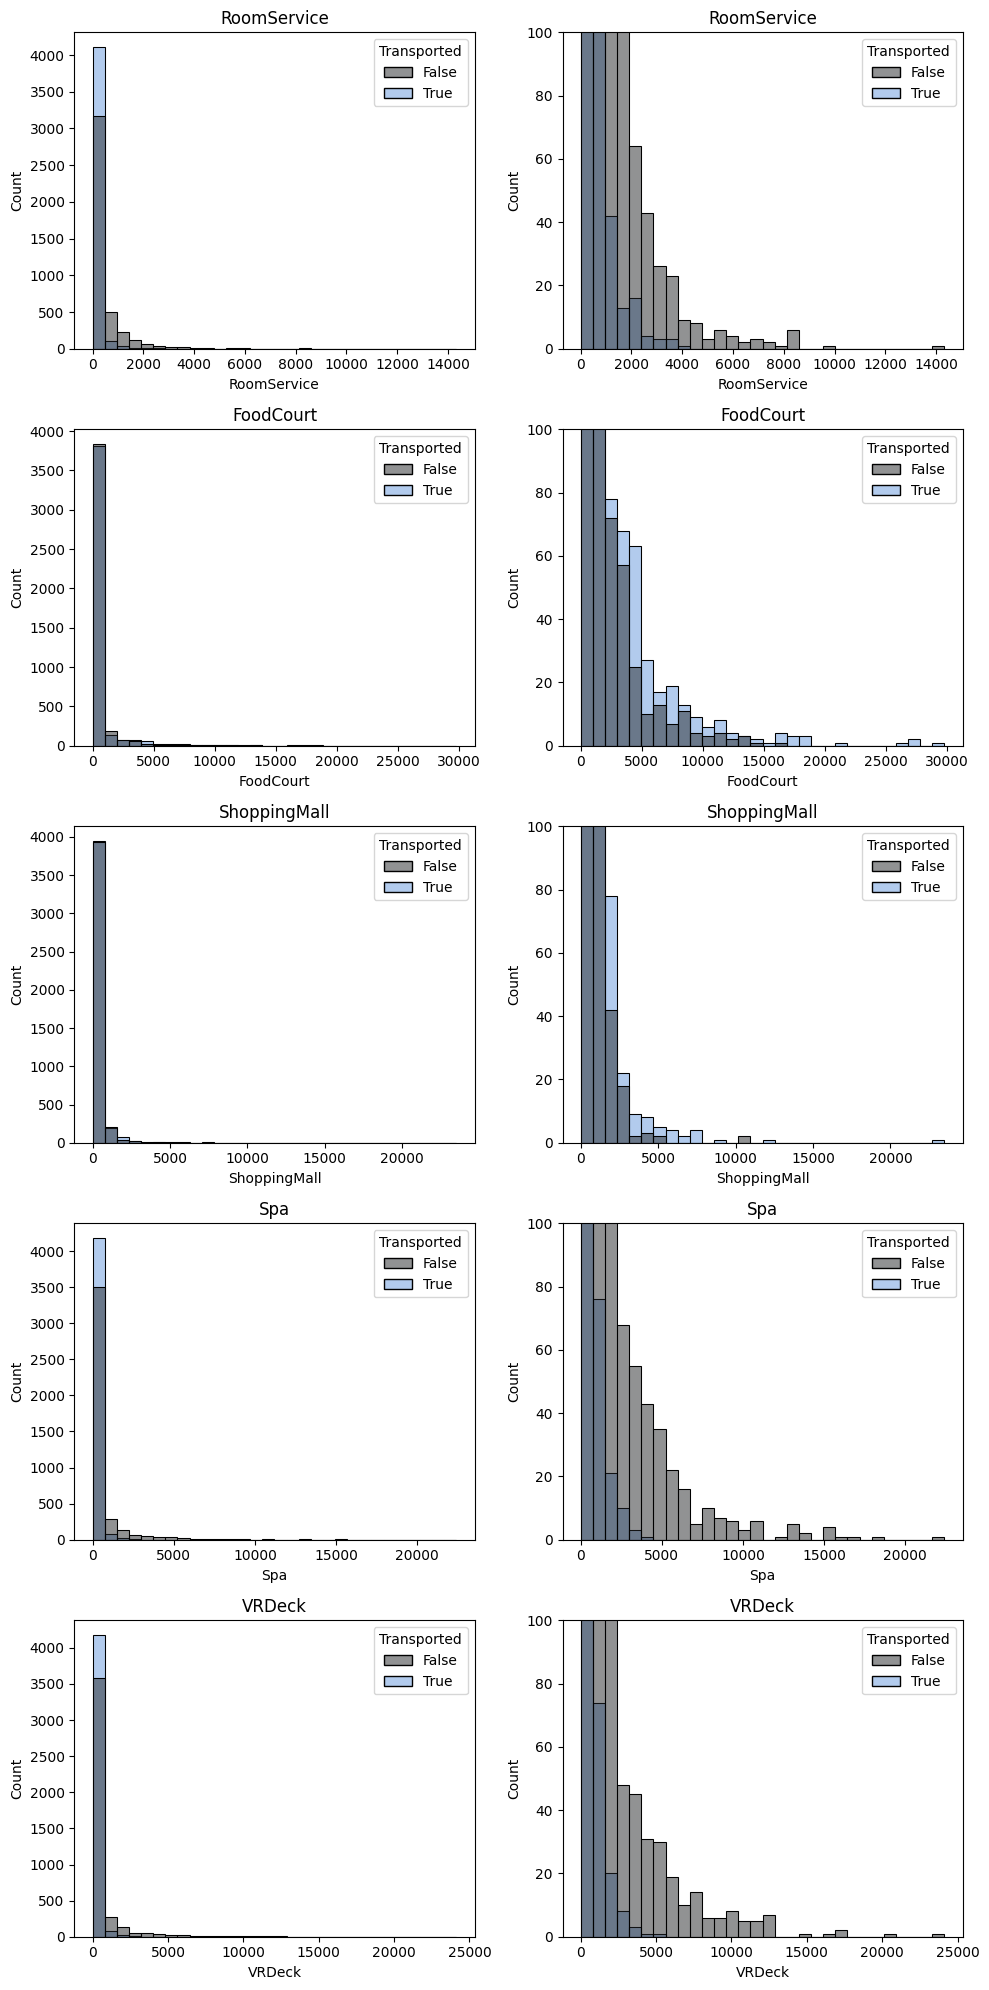

In [10]:
exp_feats = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig = plt.figure(figsize = (10, 20))
for i, var_name in enumerate(exp_feats):
    #Left Plot
    ax = fig.add_subplot(5, 2, 2*i+1)
    sns.histplot(data = train, x = var_name, hue = 'Transported', bins = 30, axes = ax, palette = 'dark:#69d')
    ax.set_title(var_name)

    #Right Plot
    ax = fig.add_subplot(5, 2, 2*i+2)
    sns.histplot(data = train, x = var_name, hue = 'Transported', bins = 30, axes = ax, palette = 'dark:#69d')
    ax.set_title(var_name)
    plt.ylim(0, 100)
    
plt.tight_layout()
plt.show()


## Categorical Feature Analysis

We explore:

- HomePlanet
- CryoSleep
- Destination
- VIP
- Cabin deck & side

Count plots help us understand how categories relate to the target variable.

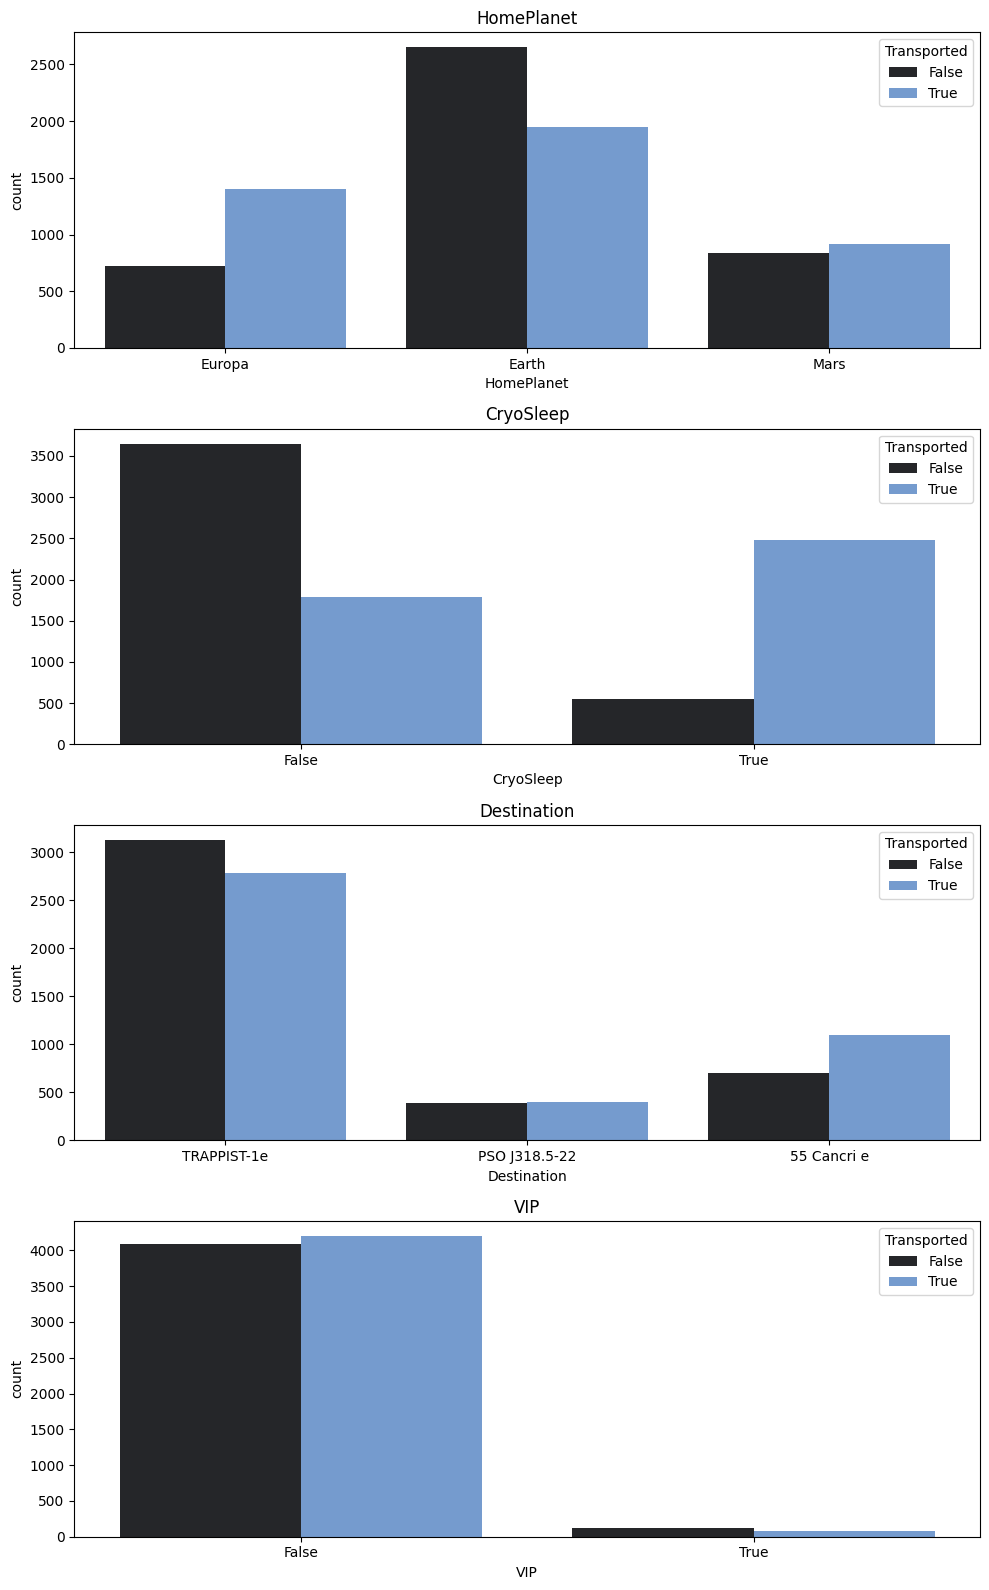

In [11]:
cat_feats=['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig = plt.figure(figsize = (10, 16))
for i, var_name in enumerate(cat_feats):
    ax = fig.add_subplot(4, 1, i+1)
    sns.countplot(data = train, x = var_name, hue = 'Transported', axes = ax, palette = 'dark:#69d')
    ax.set_title(var_name)
    
plt.tight_layout()
plt.show()

In [12]:
qual_feats=['PassengerId', 'Cabin' ,'Name']

train[qual_feats].head()

,PassengerId,Cabin,Name
0,0001_01,B/0/P,Maham Ofracculy
1,0002_01,F/0/S,Juanna Vines
2,0003_01,A/0/S,Altark Susent
3,0003_02,A/0/S,Solam Susent
4,0004_01,F/1/S,Willy Santantines


# 4. Feature Engineering

In this section, we create new meaningful features to improve model performance.

The goal is to extract hidden patterns from:

- Age
- Spending behavior
- Passenger groups
- Cabin structure

---

## Age Grouping

We convert continuous age into categorical age groups:

- Age_0-12
- Age_13-17
- Age_18-25
- Age_26-30
- Age_31-50
- Age_51+

This helps capture non-linear survival patterns.


<Axes: xlabel='Age_group', ylabel='count'>

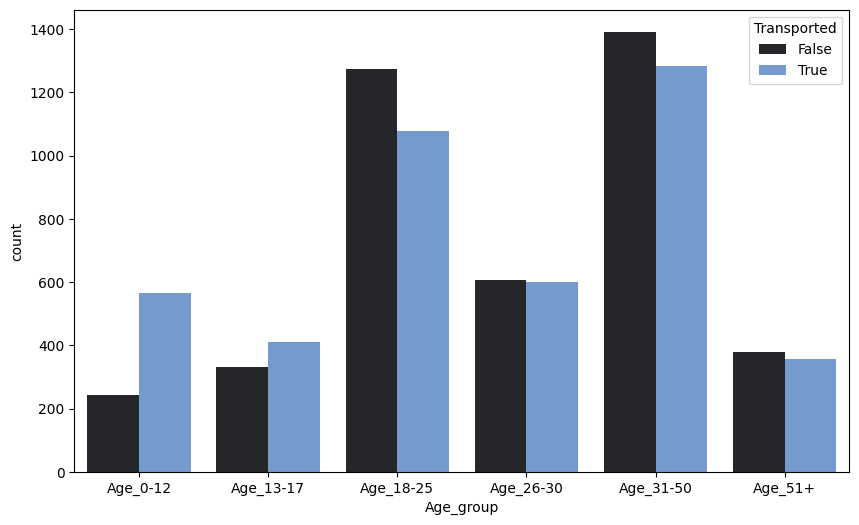

In [13]:
train['Age_group'] = pd.Series(dtype='object')
train.loc[(train['Age'] <= 12), 'Age_group'] = 'Age_0-12'
train.loc[(train['Age'] > 12) & (train['Age'] <= 17), 'Age_group'] = 'Age_13-17'
train.loc[(train['Age'] > 17) & (train['Age'] <= 25), 'Age_group'] = 'Age_18-25'
train.loc[(train['Age'] > 25) & (train['Age'] <= 30), 'Age_group'] = 'Age_26-30'
train.loc[(train['Age'] > 30) & (train['Age'] <= 50), 'Age_group'] = 'Age_31-50'
train.loc[(train['Age'] > 50), 'Age_group'] = 'Age_51+'

test['Age_group'] = pd.Series(dtype='object')
test.loc[(test['Age'] <= 12), 'Age_group'] = 'Age_0-12'
test.loc[(test['Age'] > 12) & (test['Age'] <= 17), 'Age_group'] = 'Age_13-17'
test.loc[(test['Age'] > 17) & (test['Age'] <= 25), 'Age_group'] = 'Age_18-25'
test.loc[(test['Age'] > 25) & (test['Age'] <= 30), 'Age_group'] = 'Age_26-30'
test.loc[(test['Age'] > 30) & (test['Age'] <= 50), 'Age_group'] = 'Age_31-50'
test.loc[(test['Age'] > 50), 'Age_group'] = 'Age_51+'

plt.figure(figsize = (10,6))
sns.countplot(data = train, x = 'Age_group', hue = 'Transported', order=['Age_0-12','Age_13-17','Age_18-25','Age_26-30','Age_31-50','Age_51+'], palette = 'dark:#69d')


## Total Expenditure & Spending Behavior

We aggregate spending-related features:

- RoomService
- FoodCourt
- ShoppingMall
- Spa
- VRDeck

Created features:

- `Expenditure` → Total spending
- `No_spending` → Binary indicator for zero spending

These features help capture passenger behavior differences.

Text(0.5, 1.0, 'No spending indicator')

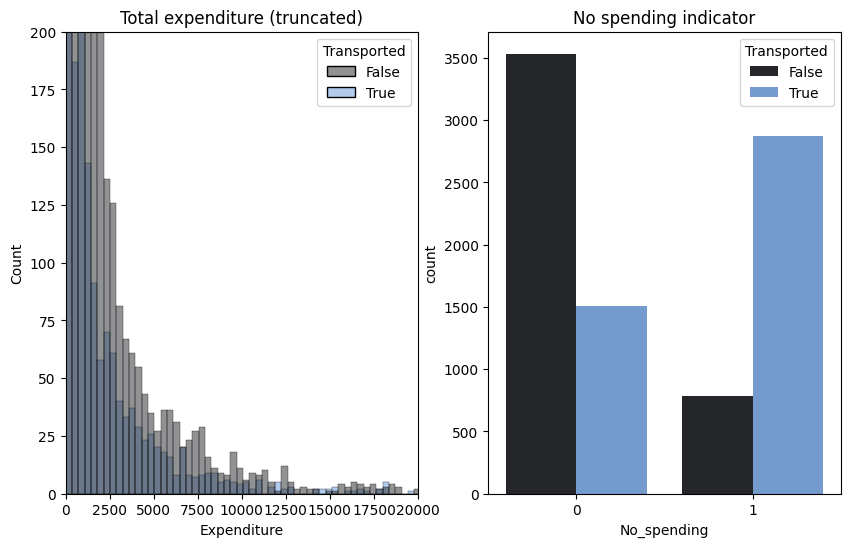

In [14]:
train['Expenditure'] = train[exp_feats].sum(axis = 1)
train['No_spending'] = (train['Expenditure'] == 0).astype(int)

test['Expenditure'] = test[exp_feats].sum(axis = 1)
test['No_spending'] = (test['Expenditure'] == 0).astype(int)

plt.figure(figsize = (10,6))
plt.subplot(1, 2, 1)
sns.histplot(data = train, x = 'Expenditure', hue = 'Transported', bins = 100, palette = 'dark:#69d')
plt.title('Total expenditure (truncated)')
plt.ylim([0,200])
plt.xlim([0,20000])

plt.subplot(1, 2, 2)
sns.countplot(data = train, x = 'No_spending', hue = 'Transported', palette = 'dark:#69d')
plt.title('No spending indicator')


## Group-Based Features

PassengerId contains group information.

We extract:

- `Group` → Passenger group ID
- `Group_size` → Number of passengers in the same group
- `Solo` → Indicator if passenger is traveling alone

Group size is often highly predictive in disaster-style datasets.

Text(0.5, 1.0, 'Group Size')

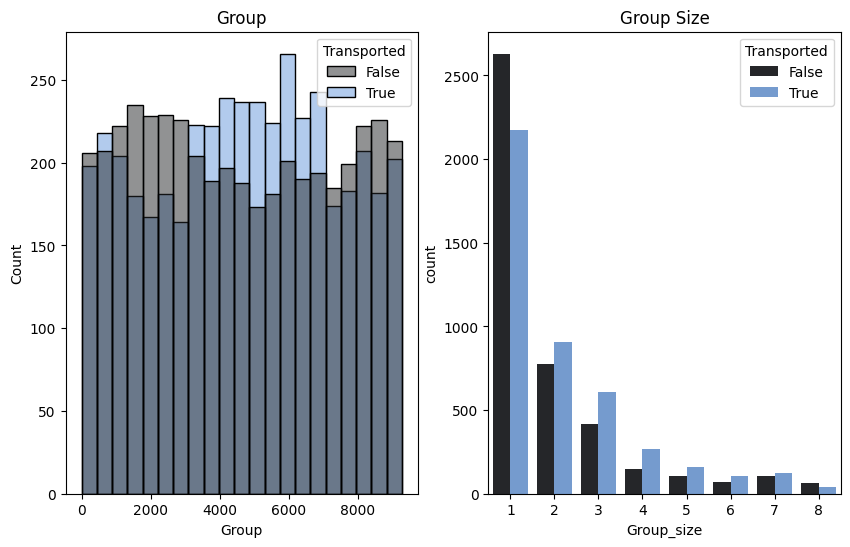

In [15]:
train['Group'] = train['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)
test['Group'] = test['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)

group_counts = pd.concat([train['Group'], test['Group']]).value_counts()

train['Group_size'] = train['Group'].map(group_counts)
test['Group_size']=test['Group'].map(group_counts)

plt.figure(figsize = (10,6))
plt.subplot(1, 2, 1)
sns.histplot(data = train, x = 'Group', hue = 'Transported', palette = 'dark:#69d')
plt.title('Group')

plt.subplot(1, 2, 2)
sns.countplot(data = train, x = 'Group_size', hue = 'Transported', palette = 'dark:#69d')
plt.title('Group Size')

## Cabin Feature Decomposition

We split the `Cabin` column into:

- Cabin_deck
- Cabin_number
- Cabin_side

We further engineer cabin region features based on cabin number ranges to capture spatial patterns within the ship.

Text(0.5, 1.0, 'Passenger travelling solo')

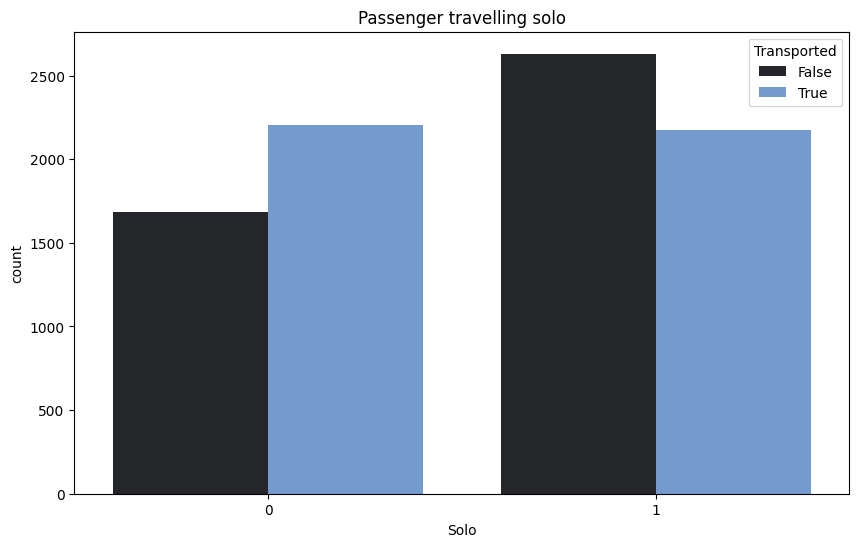

In [16]:
train['Solo'] = (train['Group_size'] == 1).astype(int)
test['Solo'] = (test['Group_size'] == 1).astype(int)

plt.figure(figsize = (10,6))
sns.countplot(data = train, x = 'Solo', hue = 'Transported', palette = 'dark:#69d')
plt.title('Passenger travelling solo')

Cabin Location

C:\Users\dell\AppData\Local\Temp\ipykernel_15564\4040265045.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Cabin'].fillna('Z/9999/Z', inplace = True)
C:\Users\dell\AppData\Local\Temp\ipykernel_15564\4040265045.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

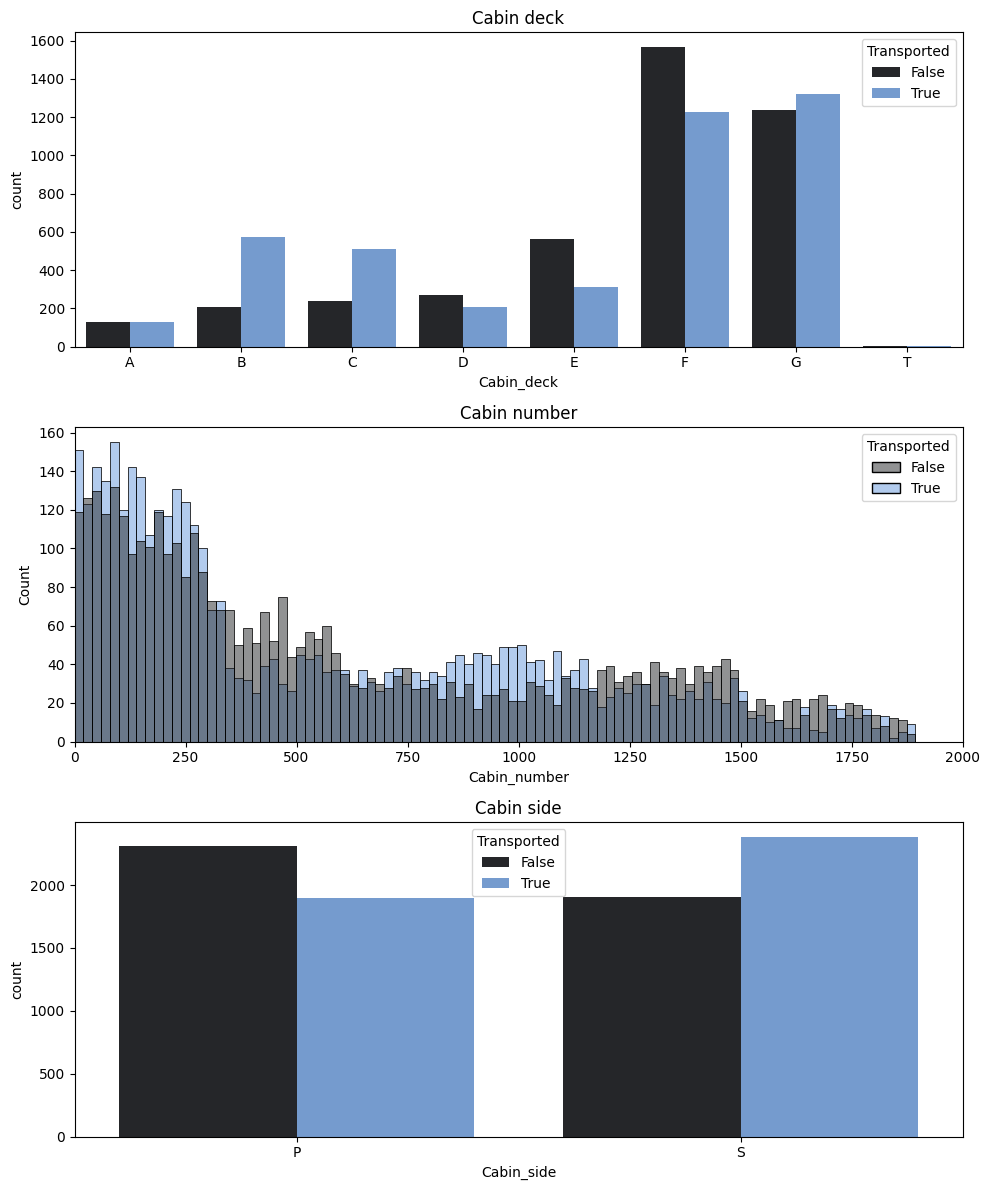

In [17]:
train['Cabin'].fillna('Z/9999/Z', inplace = True)
train['Cabin_deck'] = train['Cabin'].apply(lambda x: x.split('/')[0])
train['Cabin_number'] = train['Cabin'].apply(lambda x: x.split('/')[1]).astype(int)
train['Cabin_side'] = train['Cabin'].apply(lambda x: x.split('/')[2])

test['Cabin'].fillna('Z/9999/Z', inplace = True)
test['Cabin_deck'] = test['Cabin'].apply(lambda x: x.split('/')[0])
test['Cabin_number'] = test['Cabin'].apply(lambda x: x.split('/')[1]).astype(int)
test['Cabin_side'] = test['Cabin'].apply(lambda x: x.split('/')[2])

train.loc[train['Cabin_deck'] == 'Z', 'Cabin_deck'] = np.nan
train.loc[train['Cabin_number'] == 9999, 'Cabin_number'] = np.nan
train.loc[train['Cabin_side'] == 'Z', 'Cabin_side'] = np.nan
test.loc[test['Cabin_deck'] == 'Z', 'Cabin_deck'] = np.nan
test.loc[test['Cabin_number'] == 9999, 'Cabin_number'] = np.nan
test.loc[test['Cabin_side'] == 'Z', 'Cabin_side'] = np.nan

train.drop('Cabin', axis = 1, inplace = True)
test.drop('Cabin', axis = 1, inplace = True)

fig=plt.figure(figsize = (10,12))
plt.subplot(3,1,1)
sns.countplot(data = train, x = 'Cabin_deck', hue = 'Transported', order = ['A','B','C','D','E','F','G','T'], palette = 'dark:#69d')
plt.title('Cabin deck')

plt.subplot(3,1,2)
sns.histplot(data = train, x = 'Cabin_number', hue = 'Transported',binwidth = 20, palette = 'dark:#69d')
plt.title('Cabin number')
plt.xlim([0,2000])

plt.subplot(3,1,3)
sns.countplot(data = train, x = 'Cabin_side', hue = 'Transported', palette = 'dark:#69d')
plt.title('Cabin side')

plt.tight_layout()

Cabin Region

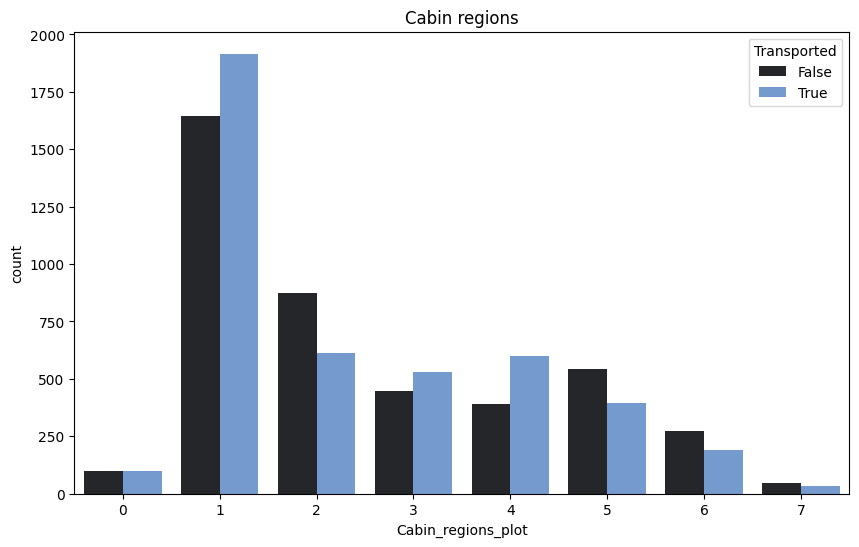

In [18]:
# New features - training set
train['Cabin_region1'] = (train['Cabin_number']<300).astype(int)   # one-hot encoding
train['Cabin_region2'] = ((train['Cabin_number']>=300) & (train['Cabin_number']<600)).astype(int)
train['Cabin_region3'] = ((train['Cabin_number']>=600) & (train['Cabin_number']<900)).astype(int)
train['Cabin_region4'] = ((train['Cabin_number']>=900) & (train['Cabin_number']<1200)).astype(int)
train['Cabin_region5'] = ((train['Cabin_number']>=1200) & (train['Cabin_number']<1500)).astype(int)
train['Cabin_region6'] = ((train['Cabin_number']>=1500) & (train['Cabin_number']<1800)).astype(int)
train['Cabin_region7'] = (train['Cabin_number']>=1800).astype(int)

# New features - test set
test['Cabin_region1'] = (test['Cabin_number']<300).astype(int)   # one-hot encoding
test['Cabin_region2'] = ((test['Cabin_number']>=300) & (test['Cabin_number']<600)).astype(int)
test['Cabin_region3'] = ((test['Cabin_number']>=600) & (test['Cabin_number']<900)).astype(int)
test['Cabin_region4'] = ((test['Cabin_number']>=900) & (test['Cabin_number']<1200)).astype(int)
test['Cabin_region5'] = ((test['Cabin_number']>=1200) & (test['Cabin_number']<1500)).astype(int)
test['Cabin_region6'] = ((test['Cabin_number']>=1500) & (test['Cabin_number']<1800)).astype(int)
test['Cabin_region7'] = (test['Cabin_number']>=1800).astype(int)

# Plot distribution of new features
plt.figure(figsize=(10,6))
train['Cabin_regions_plot'] = (train['Cabin_region1'] + 2*train['Cabin_region2'] + 3*train['Cabin_region3'] + 4*train['Cabin_region4'] + 5*train['Cabin_region5'] + 6*train['Cabin_region6'] + 7*train['Cabin_region7']).astype(int)
sns.countplot(data = train, x = 'Cabin_regions_plot', hue = 'Transported', palette = 'dark:#69d')
plt.title('Cabin regions')
train.drop('Cabin_regions_plot', axis = 1, inplace = True)

Family Name

C:\Users\dell\AppData\Local\Temp\ipykernel_15564\1390367889.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Name'].fillna('Unknown Unknown', inplace = True)
C:\Users\dell\AppData\Local\Temp\ipykernel_15564\1390367889.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

Text(0.5, 1.0, 'Family size')

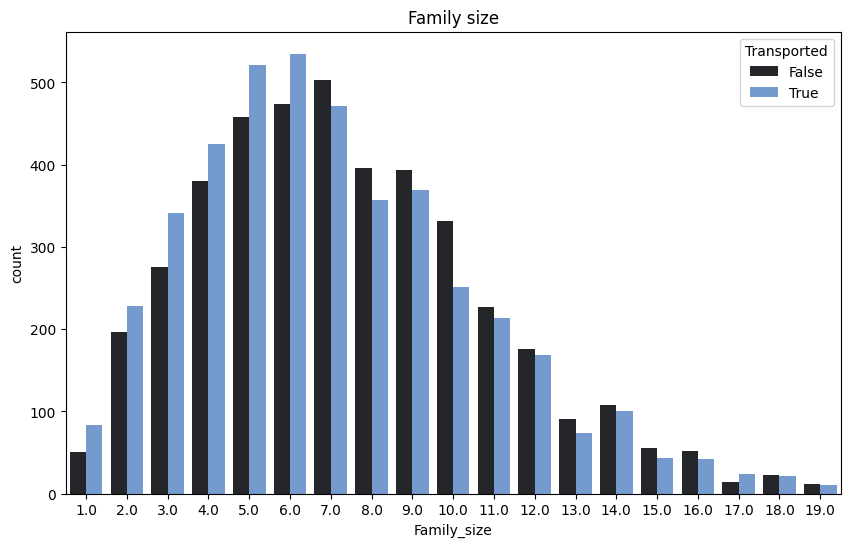

In [19]:
train['Name'].fillna('Unknown Unknown', inplace = True)
test['Name'].fillna('Unknown Unknown', inplace = True)

train['Family_name'] = train['Name'].str.split().str[-1]
test['Family_name'] = test['Name'].str.split().str[-1]

all_names = pd.concat([train['Family_name'], test['Family_name']])
family_counts = all_names.value_counts()

train['Family_size'] = train['Family_name'].map(family_counts)
test['Family_size'] = test['Family_name'].map(family_counts)

train.loc[train['Family_name'] == 'Unknown','Family_name'] = np.nan
train.loc[train['Family_size'] > 100,'Family_size'] = np.nan
test.loc[test['Family_name'] == 'Unknown','Family_name'] = np.nan
test.loc[test['Family_size'] > 100, 'Family_size'] = np.nan

train.drop('Name', axis = 1, inplace = True)
test.drop('Name', axis = 1, inplace = True)

plt.figure(figsize = (10, 6))
sns.countplot(data = train, x = 'Family_size', hue = 'Transported', palette = 'dark:#69d')
plt.title('Family size')

## Summary of Engineered Features

New features created:

- Age_group
- Expenditure
- No_spending
- Group
- Group_size
- Solo
- Cabin_deck
- Cabin_number
- Cabin_side
- Cabin_region1–7
- Family_size

These features will be used in the modeling phase.

# 5. Handling Missing Values

In [20]:
# Target and Features
y = train['Transported'].copy()
X = train.drop('Transported', axis = 1).copy()

all_data = pd.concat([X, test], axis = 0).reset_index()
all_data

,index,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Cabin_side,Cabin_region1,Cabin_region2,Cabin_region3,Cabin_region4,Cabin_region5,Cabin_region6,Cabin_region7,Family_name,Family_size
0,0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,P,1,0,0,0,0,0,0,Ofracculy,3.0
1,1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,S,1,0,0,0,0,0,0,Vines,4.0
2,2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,S,1,0,0,0,0,0,0,Susent,7.0
3,3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,S,1,0,0,0,0,0,0,Susent,7.0
4,4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,S,1,0,0,0,0,0,0,Santantines,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,4272,9266_02,Earth,True,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,...,S,0,0,0,0,1,0,0,Peter,10.0
12966,4273,9269_01,Earth,False,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,...,NaN,0,0,0,0,0,0,0,Scheron,6.0
12967,4274,9271_01,Mars,True,55 Cancri e,NaN,False,0.0,0.0,0.0,...,P,1,0,0,0,0,0,0,Pore,4.0
12968,4275,9273_01,Europa,False,NaN,NaN,False,0.0,2680.0,0.0,...,P,1,0,0,0,0,0,0,Conale,7.0


In [21]:
# Columns with missing values
na_cols = all_data.columns[all_data.isna().any()].to_list()

# Summary of missing values
missing_values = pd.DataFrame(all_data[na_cols].isna().sum(), columns = ['Number_missing'])
missing_values['Percent_missing'] = (missing_values['Number_missing'] / len(all_data)) * 100

missing_values

,Number_missing,Percent_missing
HomePlanet,288,2.220509
CryoSleep,310,2.390131
Destination,274,2.112567
Age,270,2.081727
VIP,296,2.282190
RoomService,263,2.027756
FoodCourt,289,2.228219
ShoppingMall,306,2.359291
Spa,284,2.189668
VRDeck,268,2.066307


We can see that missing values are not alot

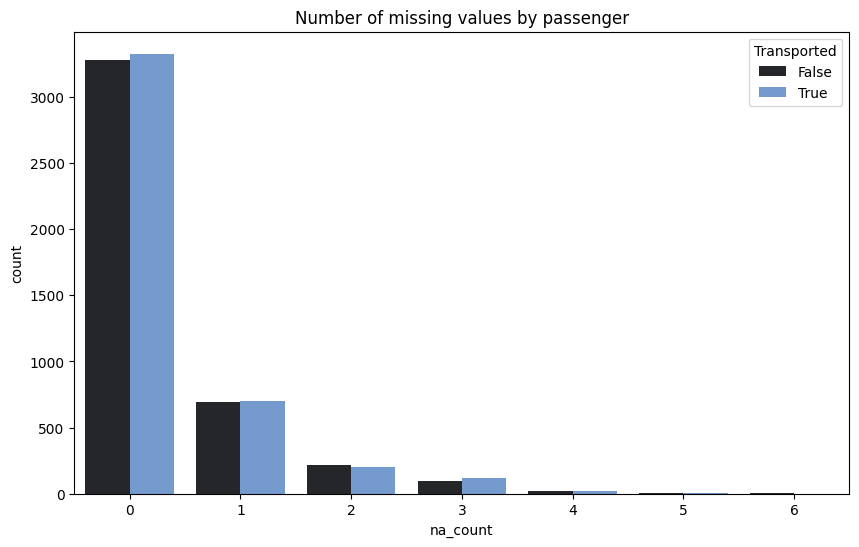

In [22]:
# Countplot of number of missing values by passenger
train['na_count'] = train.isna().sum(axis = 1)
plt.figure(figsize = (10,6))
sns.countplot(data = train, x = 'na_count', hue = 'Transported', palette = 'dark:#69d')
plt.title('Number of missing values by passenger')
train.drop('na_count', axis=1, inplace=True)


In [23]:
GHP_count = all_data.groupby(['Group','HomePlanet'])['HomePlanet'].size().unstack().fillna(0)
GHP_count.head()

HomePlanet,Earth,Europa,Mars
Group,,,
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,2.0,0.0
4,1.0,0.0,0.0
5,1.0,0.0,0.0


In [24]:
GHP_prob = GHP_count.div(GHP_count.sum(axis = 1), axis = 0)
GHP_prob.sum(axis = 1).nunique()

1

can use group to fill homeplanet

In [25]:
HP_bef=all_data['HomePlanet'].isna().sum()

missing_hp = all_data['HomePlanet'].isna()
valid_group = all_data['Group'].isin(GHP_count.index)
GHP_index = all_data.loc[missing_hp & valid_group].index

group_to_planet = GHP_count.idxmax(axis = 1)

all_data.loc[GHP_index,'HomePlanet'] = all_data.loc[GHP_index, 'Group'].map(group_to_planet)

# Print number of missing values left
print('#HomePlanet missing values before:',HP_bef)
print('#HomePlanet missing values after:',all_data['HomePlanet'].isna().sum())


#HomePlanet missing values before: 288
#HomePlanet missing values after: 157


homeplanet and cabin deck

<Axes: xlabel='HomePlanet', ylabel='Cabin_deck'>

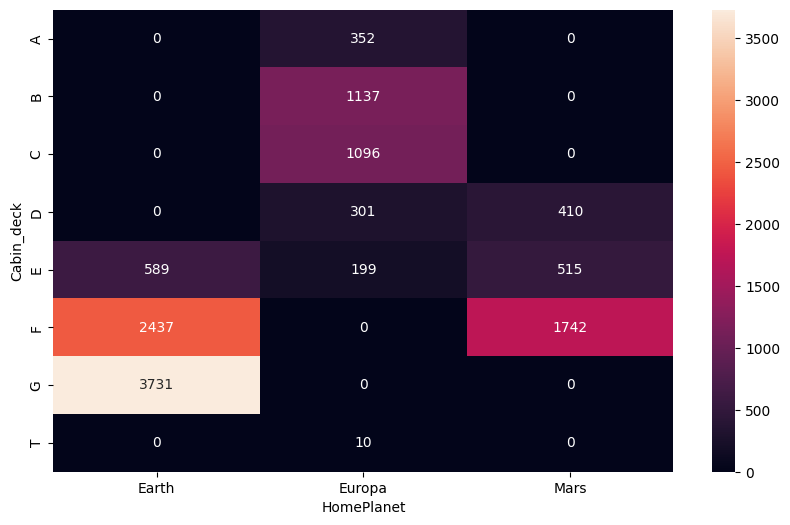

In [26]:
CDHP_count = all_data.groupby(['Cabin_deck','HomePlanet'])['HomePlanet'].size().unstack().fillna(0)

plt.figure(figsize = (10,6))
sns.heatmap(CDHP_count, annot = True, fmt='g')

we can see a, b, c came from europa - g came from earth - d e f from multiple planets

In [27]:
HP_bef = all_data['HomePlanet'].isna().sum()

mask = (all_data['HomePlanet'].isna()) & (all_data['Cabin_deck'].isin(['A', 'B', 'C', 'T']))
all_data.loc[mask, 'HomePlanet'] = 'Europa'

mask = (all_data['HomePlanet'].isna()) & (all_data['Cabin_deck'].isin(['G']))
all_data.loc[mask, 'HomePlanet'] = 'Earth'

# Print number of missing values left
print('#HomePlanet missing values before:', HP_bef)
print('#HomePlanet missing values after:', all_data['HomePlanet'].isna().sum())

#HomePlanet missing values before: 157
#HomePlanet missing values after: 94


Homeplanet and family name

In [28]:
FNHP_count = all_data.groupby(['Family_name', 'HomePlanet']).size().unstack().fillna(0)
FNHP_count.head()

HomePlanet,Earth,Europa,Mars
Family_name,,,
Acobson,5.0,0.0,0.0
Acobsond,8.0,0.0,0.0
Adavisons,10.0,0.0,0.0
Adkinson,4.0,0.0,0.0
Admingried,0.0,4.0,0.0


In [29]:
FNHP_prob = FNHP_count.div(FNHP_count.sum(axis = 1), axis = 0)
FNHP_prob.sum(axis = 1).nunique()

1

Everyone with the same surname comes from the same home planet.

In [30]:
HP_bef = all_data['HomePlanet'].isna().sum()

missing_hp = all_data['HomePlanet'].isna()
valid_family = all_data['Family_name'].isin(FNHP_count.index)
FNHP_index = all_data.loc[missing_hp & valid_family].index

surname_to_planet = FNHP_count.idxmax(axis = 1)
all_data.loc[FNHP_index, 'HomePlanet'] = all_data.iloc[FNHP_index, :]['Family_name'].map(surname_to_planet)

# Print number of missing values left
print('#HomePlanet missing values before:', HP_bef)
print('#HomePlanet missing values after:', all_data['HomePlanet'].isna().sum())

#HomePlanet missing values before: 94
#HomePlanet missing values after: 10


In [31]:
all_data[all_data['HomePlanet'].isna()][['PassengerId','HomePlanet','Destination']]

,PassengerId,HomePlanet,Destination
2274,2443_01,NaN,TRAPPIST-1e
2631,2817_01,NaN,TRAPPIST-1e
3091,3331_01,NaN,TRAPPIST-1e
4548,4840_01,NaN,TRAPPIST-1e
5762,6108_01,NaN,TRAPPIST-1e
8969,0616_01,NaN,TRAPPIST-1e
10583,4052_01,NaN,TRAPPIST-1e
11913,7065_01,NaN,TRAPPIST-1e
12551,8435_01,NaN,TRAPPIST-1e
12725,8775_01,NaN,TRAPPIST-1e


In [32]:
DHP_count = all_data.groupby(['HomePlanet', 'Destination']).size().unstack().fillna(0)
DHP_count

Destination,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
HomePlanet,,,
Earth,1000,1085,4778
Europa,1341,29,1769
Mars,300,70,2314


In [33]:
HP_bef = all_data['HomePlanet'].isna().sum()

all_data.loc[(all_data['HomePlanet'].isna()) & ~(all_data['Cabin_deck']=='D'), 'HomePlanet']='Earth'
all_data.loc[(all_data['HomePlanet'].isna()) & (all_data['Cabin_deck']=='D'), 'HomePlanet']='Mars'

print('#HomePlanet missing values before:', HP_bef)
print('#HomePlanet missing values after:', all_data['HomePlanet'].isna().sum())


#HomePlanet missing values before: 10
#HomePlanet missing values after: 0


most people going to TRAPPIST-1e using mode

In [34]:
D_bef = all_data['Destination'].isna().sum()

all_data.loc[(all_data['Destination'].isna()), 'Destination'] = 'TRAPPIST-1e'

print('#HomePlanet missing values before:', D_bef)
print('#HomePlanet missing values after:', all_data['Destination'].isna().sum())

#HomePlanet missing values before: 274
#HomePlanet missing values after: 0


Family name and group

C:\Users\dell\AppData\Local\Temp\ipykernel_15564\2467596777.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = (FNG_count > 0).sum(axis=1), palette = 'dark:#69d')


<Axes: xlabel='None', ylabel='count'>

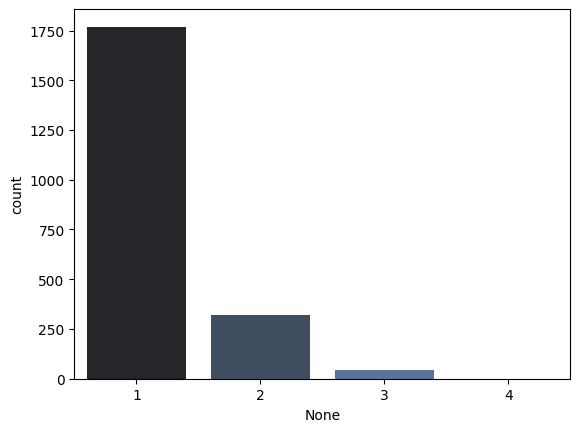

In [35]:
mask = all_data['Group_size'] > 1
FNG_count = all_data[mask].groupby(['Group', 'Family_name'])['Family_name'].size().unstack().fillna(0)

sns.countplot(x = (FNG_count > 0).sum(axis=1), palette = 'dark:#69d')


The majority (83%) of groups contain only 1 family. So let's fill missing surnames according to the majority surname in that group.

In [36]:
SN_bef = all_data['Family_name'].isna().sum()

mask1 = all_data['Family_name'].isna()
mask2 = all_data['Group'].isin(FNG_count.index)
FNG_index = all_data[mask1 & mask2].index

all_data.loc[FNG_index, 'Family_name'] = all_data.iloc[FNG_index, :]['Group'].map(lambda x: FNG_count.idxmax(axis=1)[x])

print('#Family name missing values before:', SN_bef)
print('#Family name missing values after:', all_data['Family_name'].isna().sum())

#Family name missing values before: 294
#Family name missing values after: 155


That is the best we can do. We don't have to get rid of all of these missing values because we will end up dropping the surname feature anyway. However, we can update the family size feature.

In [37]:
# Replace NaN's with outliers (so we can use map)
all_data['Family_name'].fillna('Unknown', inplace=True)

# Update family size feature
all_data['Family_size'] = all_data['Family_name'].map(lambda x: all_data['Family_name'].value_counts()[x])

# Put NaN's back in place of outliers
mask = all_data['Family_name'] == 'Unknown'
all_data.loc[mask, 'Family_name'] = np.nan

# Say unknown surname means no family
mask = all_data['Family_size'] > 100
all_data.loc[mask, 'Family_size'] = 0

C:\Users\dell\AppData\Local\Temp\ipykernel_15564\3238607708.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_data['Family_name'].fillna('Unknown', inplace=True)


CabinSide and Group

C:\Users\dell\AppData\Local\Temp\ipykernel_15564\3878825673.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = (GCD_count> 0).sum(axis = 1), palette = 'dark:#69d')
C:\Users\dell\AppData\Local\Temp\ipykernel_15564\3878825673.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = (GCN_count> 0).sum(axis = 1), palette = 'dark:#69d')
C:\Users\dell\AppData\Local\Temp\ipykernel_15564\3878825673.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = (GCS_count> 0 ).sum(axis = 1), palette = 'dark:#69d')


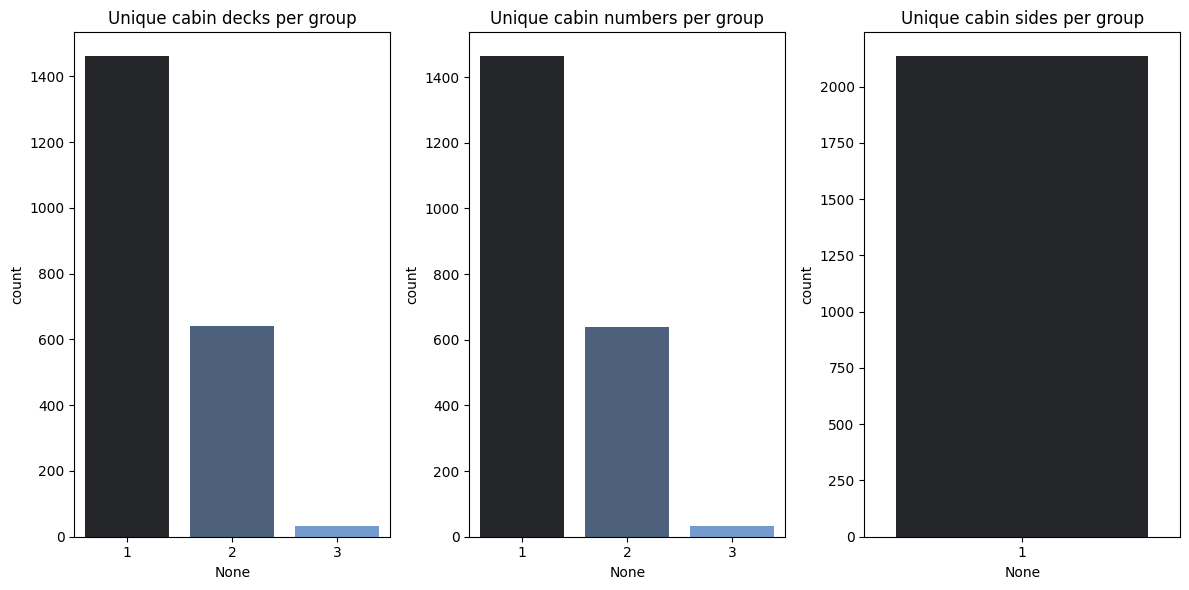

In [38]:
mask = all_data['Group_size'] > 1
GCD_count = all_data[mask].groupby(['Group', 'Cabin_deck'])['Cabin_deck'].size().unstack().fillna(0)
GCN_count = all_data[mask].groupby(['Group', 'Cabin_number'])['Cabin_number'].size().unstack().fillna(0)
GCS_count = all_data[mask].groupby(['Group', 'Cabin_side'])['Cabin_side'].size().unstack().fillna(0)

plt.figure(figsize = (12,6))
plt.subplot(1, 3, 1)
sns.countplot(x = (GCD_count> 0).sum(axis = 1), palette = 'dark:#69d')
plt.title('Unique cabin decks per group')

plt.subplot(1, 3, 2)
sns.countplot(x = (GCN_count> 0).sum(axis = 1), palette = 'dark:#69d')
plt.title('Unique cabin numbers per group')

plt.subplot(1, 3, 3)
sns.countplot(x = (GCS_count> 0 ).sum(axis = 1), palette = 'dark:#69d')
plt.title('Unique cabin sides per group')
plt.tight_layout()

Another rule! Everyone in the same group is also on the same cabin side. For cabin deck and cabin number there is also a fairly good (but not perfect) correlation with group.

In [ ]:
# Missing values before
CS_bef=all_data['Cabin_side'].isna().sum()

# Passengers with missing Cabin side and in a group with known Cabin side
mask1 = all_data['Cabin_side'].isna()
mask2 = all_data['Group'].isin(GCS_count.index)
GCS_index = all_data[mask1 & mask2].index

# Fill corresponding missing values
all_data.loc[GCS_index,'Cabin_side'] = all_data.iloc[GCS_index,:]['Group'].map(lambda x: GCS_count.idxmax(axis=1)[x])

# Print number of missing values left
print('Cabin_side missing values before:', CS_bef)
print('Cabin_side missing values after:', all_data['Cabin_side'].isna().sum())

#Cabin_side missing values before: 162
#Cabin_side missing values after: 162


CabinSide and Family name

C:\Users\dell\AppData\Local\Temp\ipykernel_15564\3385456328.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = FNCS_count['Ratio'], binwidth = 0.1, palette = 'dark:#69d')


Text(0.5, 1.0, 'Ratio of cabin side by surname')

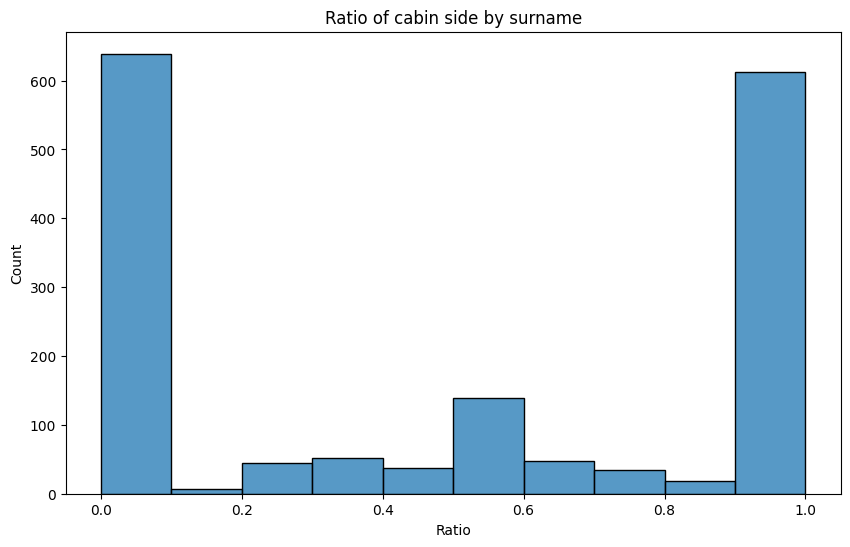

In [53]:
mask = all_data['Group_size'] > 1
FNCS_count = all_data[mask].groupby(['Family_name', 'Cabin_side'])['Cabin_side'].size().unstack().fillna(0)
FNCS_count['Ratio'] = FNCS_count['P'] / (FNCS_count['P'] + FNCS_count['S'])

plt.figure(figsize=(10,6))
sns.histplot(x = FNCS_count['Ratio'], binwidth = 0.1, palette = 'dark:#69d')
plt.title('Ratio of cabin side by surname')

In [48]:
print('Percentage of families all on the same cabin side:', 100*np.round((FNCS_count['Ratio'].isin([0,1])).sum()/len(FNCS_count),3),'%')

# Another view of the same information
FNCS_count.head()

Percentage of families all on the same cabin side: 76.7 %


Cabin_side,P,S,Ratio
Family_name,,,
Acobson,0.0,3.0,0.0
Acobsond,3.0,0.0,1.0
Adavisons,6.0,0.0,1.0
Admingried,0.0,4.0,0.0
Aginge,3.0,0.0,1.0


In [54]:
# Missing values before
CS_bef=all_data['Cabin_side'].isna().sum()

# Drop ratio column
FNCS_count.drop('Ratio', axis = 1, inplace = True)

# Passengers with missing Cabin side and in a family with known Cabin side
mask1 = all_data['Cabin_side'].isna()
mask2 = all_data[mask1]['Family_name'].isin(FNCS_count.index)
FNCS_index = all_data[mask1 & mask2].index

# Fill corresponding missing values
all_data.loc[FNCS_index,'Cabin_side']=all_data.iloc[FNCS_index,:]['Family_name'].map(lambda x: FNCS_count.idxmax(axis=1)[x])

# Drop surname (we don't need it anymore)
all_data.drop('Family_name', axis=1, inplace=True)

# Print number of missing values left
print('#Cabin_side missing values before:',CS_bef)
print('#Cabin_side missing values after:',all_data['Cabin_side'].isna().sum())

#Cabin_side missing values before: 162
#Cabin_side missing values after: 66


The remaining missing values will be replaced with an outlier. This is because we really don't know which one of the two (balanced) sides we should assign.

In [55]:
# Missing values before
CS_bef = all_data['Cabin_side'].isna().sum()

# Fill remaining missing values with outlier
all_data.loc[all_data['Cabin_side'].isna(),'Cabin_side']='Z'

# Print number of missing values left
print('#Cabin_side missing values before:',CS_bef)
print('#Cabin_side missing values after:',all_data['Cabin_side'].isna().sum())

#Cabin_side missing values before: 66
#Cabin_side missing values after: 0


CabinDeck and Group

In [56]:
CD_bef = all_data['Cabin_deck'].isna().sum()

mask1 = all_data['Cabin_deck'].isna()
mask2 = all_data[mask1]['Group'].isin(GCD_count.index)
GCD_index = all_data[mask1 & mask2].index

all_data.loc[GCD_index,'Cabin_deck'] = all_data.iloc[GCD_index,:]['Group'].map(lambda x: GCD_count.idxmax(axis = 1)[x])

print('Cabin_deck missing values before:', CD_bef)
print('Cabin_deck missing values after:', all_data['Cabin_deck'].isna().sum())

Cabin_deck missing values before: 299
Cabin_deck missing values after: 162


CabinDeck and HomePlanet

In [58]:
all_data.groupby(['HomePlanet','Destination','Solo','Cabin_deck'])['Cabin_deck'].size().unstack().fillna(0)

Cabin_deck                         A      B      C      D      E       F  \
HomePlanet Destination   Solo                                              
Earth      55 Cancri e   0       0.0    0.0    0.0    0.0   20.0    90.0   
                         1       0.0    0.0    0.0    0.0   47.0   289.0   
           PSO J318.5-22 0       0.0    0.0    0.0    0.0   18.0    67.0   
                         1       0.0    0.0    0.0    0.0   25.0   262.0   
           TRAPPIST-1e   0       0.0    0.0    0.0    0.0  133.0   438.0   
                         1       0.0    0.0    0.0    0.0  358.0  1350.0   
Europa     55 Cancri e   0      96.0  377.0  313.0   59.0   35.0     0.0   
                         1      67.0  141.0  159.0   46.0   34.0     0.0   
           PSO J318.5-22 0       2.0    5.0   11.0    0.0    0.0     0.0   
                         1       0.0    0.0   10.0    0.0    0.0     0.0   
           TRAPPIST-1e   0     152.0  459.0  428.0  120.0   53.0     0.0   
                         1      44.0  179.0  201.0   84.0   82.0     0.0   
Mars       55 Cancri e   0       0.0    0.0    0.0   32.0   15.0   104.0   
                         1       0.0    0.0    0.0   40.0   16.0    92.0   
           PSO J318.5-22 0       0.0    0.0    0.0    8.0    9.0    14.0   
                         1       0.0    0.0    0.0    9.0    7.0    21.0   
           TRAPPIST-1e   0       0.0    0.0    0.0  168.0  219.0   798.0   
                         1       0.0    0.0    0.0  164.0  263.0   743.0   

Cabin_deck                          G    T  
HomePlanet Destination   Solo               
Earth      55 Cancri e   0      272.0  0.0  
                         1      269.0  0.0  
           PSO J318.5-22 0      230.0  0.0  
                         1      466.0  0.0  
           TRAPPIST-1e   0     1075.0  0.0  
                         1     1509.0  0.0  
Europa     55 Cancri e   0        0.0  2.0  
                         1        0.0  0.0  
           PSO J318.5-22 0        0.0  0.0  
                         1        0.0  0.0  
           TRAPPIST-1e   0        0.0  1.0  
                         1        0.0  8.0  
Mars       55 Cancri e   0        0.0  0.0  
                         1        0.0  0.0  
           PSO J318.5-22 0        0.0  0.0  
                         1        0.0  0.0  
           TRAPPIST-1e   0        0.0  0.0  
                         1        0.0  0.0

Notes:

Passengers from Mars are most likely in deck F.
Passengers from Europa are (more or less) most likely in deck C if travelling solo and deck B otherwise.
Passengers from Earth are (more or less) most likely in deck G.

In [59]:
# Missing values before
CD_bef = all_data['Cabin_deck'].isna().sum()

# Fill missing values using the mode
na_rows_CD = all_data.loc[all_data['Cabin_deck'].isna(),'Cabin_deck'].index
all_data.loc[all_data['Cabin_deck'].isna(),'Cabin_deck']=all_data.groupby(['HomePlanet','Destination','Solo'])['Cabin_deck'].transform(lambda x: x.fillna(pd.Series.mode(x)[0]))[na_rows_CD]

# Print number of missing values left
print('#Cabin_deck missing values before:',CD_bef)
print('#Cabin_deck missing values after:',all_data['Cabin_deck'].isna().sum())

#Cabin_deck missing values before: 162
#Cabin_deck missing values after: 0


CabinNumber and CabinDeck do it later or no

VIP

mostly no vip

In [61]:
all_data['VIP'].value_counts()

VIP
False    12401
True       273
Name: count, dtype: int64

In [62]:
V_bef = all_data['VIP'].isna().sum()

mask = all_data['VIP'].isna()
all_data.loc[mask, 'VIP'] = False

print('VIP missing values before:', V_bef)
print('VIP missing values after:', all_data['VIP'].isna().sum())

VIP missing values before: 296
VIP missing values after: 0


Age

In [65]:
all_data.groupby(['HomePlanet','No_spending','Solo','Cabin_deck'])['Age'].median().unstack().fillna(0)

Cabin_deck                      A     B     C     D     E     F     G     T
HomePlanet No_spending Solo                                                
Earth      0           0      0.0   0.0   0.0   0.0  24.0  25.0  28.0   0.0
                       1      0.0   0.0   0.0   0.0  25.0  24.0  26.0   0.0
           1           0      0.0   0.0   0.0   0.0   7.0  16.0   8.0   0.0
                       1      0.0   0.0   0.0   0.0  21.0  21.5  23.0   0.0
Europa     0           0     35.0  34.0  33.0  33.0  34.0   0.0   0.0  44.0
                       1     35.0  36.0  35.5  34.0  35.0   0.0   0.0  35.0
           1           0     30.0  27.0  28.5  27.0  28.0   0.0   0.0   0.0
                       1     37.5  34.0  35.0  31.0  33.0   0.0   0.0   0.0
Mars       0           0      0.0   0.0   0.0  30.0  29.0  29.0   0.0   0.0
                       1      0.0   0.0   0.0  31.0  28.5  30.0   0.0   0.0
           1           0      0.0   0.0   0.0  29.5  26.0  18.0   0.0   0.0
                       1      0.0   0.0   0.0  33.0  30.0  29.5   0.0   0.0

In [74]:
A_bef = all_data['Age'].isna().sum()

mask = all_data['Age'].isna()
na_rows_A = all_data.loc[mask,'Age'].index

all_data.loc[mask, 'Age'] = all_data.groupby(['HomePlanet','No_spending','Solo','Cabin_deck'])['Age'].transform(lambda x: x.fillna(x.median()))[na_rows_A]

print('#Age missing values before:', A_bef)
print('#Age missing values after:', all_data['Age'].isna().sum())

#Age missing values before: 270
#Age missing values after: 0


Update age group feature

In [75]:
all_data.loc[all_data['Age']<=12,'Age_group']='Age_0-12'
all_data.loc[(all_data['Age']>12) & (all_data['Age']<18),'Age_group']='Age_13-17'
all_data.loc[(all_data['Age']>=18) & (all_data['Age']<=25),'Age_group']='Age_18-25'
all_data.loc[(all_data['Age']>25) & (all_data['Age']<=30),'Age_group']='Age_26-30'
all_data.loc[(all_data['Age']>30) & (all_data['Age']<=50),'Age_group']='Age_31-50'
all_data.loc[all_data['Age']>50,'Age_group']='Age_51+'

Cyrosleep

In [76]:
all_data.groupby(['No_spending','CryoSleep'])['CryoSleep'].size().unstack().fillna(0)

CryoSleep,False,True
No_spending,,
0,7339.0,0.0
1,740.0,4581.0
